# Semantic Normalization with LLM (NanoGPT)

This notebook is dedicated to testing and exploring text post-processing capabilities using an LLM via the NanoGPT API. We will take the "dirty" Markdown extracted in the previous stage and use a zero-temperature agent to normalize its structure and fix visual parsing artifacts (restoring run-in (inline) headings, healing fragmented or "ghost" tables, and removing hyphenation artifacts, etc.)

## Set autoreload, library importing, logging, and environment 

In [1]:
# Enable autoreload to automatically pick up changes in local modules
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import logging
import os
from pathlib import Path
from typing import List
from IPython.display import display, Markdown, Image

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field

import doc_agent 
from doc_agent.utils.logger import setup_logger
from doc_agent.ingestion.docling_parser import parse_document
from utils.extract_page import extract_page_image
from utils.encode_image import encode_image_to_base64


# Configure logging
# Local notebook logger
logger = setup_logger(
    name="002_semantic_normalization", 
    level=logging.INFO,
    log_file="notebook_experiments.log",
    log_dir=Path.cwd() / "logs"
)

logger.info("Logging system successfully initialized.")


#Get environment variables
load_dotenv(dotenv_path=Path.cwd().parent / ".env")

logger.info("Environment initialized.")

2026-04-30 21:32:48 |     INFO | 002_semantic_normalization:1644845790.py:28 - Logging system successfully initialized.
2026-04-30 21:32:48 |     INFO | 002_semantic_normalization:1644845790.py:34 - Environment initialized.


## Workspace & Path Configuration
Setting up relative paths for raw documents, interim data (extracted images and Markdown), and processed outputs.

In [3]:
# Paths relative to the notebook's location (notebooks/data/...)
notebook_root = Path.cwd()
# Path to the pdf-file
pdf_file = notebook_root / "data" / "01_raw" / "one_page.pdf"
logger.info(f"Path to the pdf-file: {pdf_file}")
# Path to the raw md-file
raw_markdown_file = notebook_root / "data" / "02_interim" / "one_page.md"
logger.info(f"Path to the md-file: {raw_markdown_file}")
# Path to the extracted page images
page_images_dir = notebook_root / "data" / "02_interim" / "page_images" 
logger.info(f"Path to the page images directory: {page_images_dir}")

docling_images_dir = notebook_root / "data" / "02_interim" / "docling_images"
logger.info(f"Path to the docling images directory: {docling_images_dir}")


2026-04-30 21:32:48 |     INFO | 002_semantic_normalization:3721074032.py:5 - Path to the pdf-file: /Volumes/SSD/AI/doc_agent/notebooks/data/01_raw/one_page.pdf
2026-04-30 21:32:48 |     INFO | 002_semantic_normalization:3721074032.py:8 - Path to the md-file: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/one_page.md
2026-04-30 21:32:48 |     INFO | 002_semantic_normalization:3721074032.py:11 - Path to the page images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/page_images
2026-04-30 21:32:48 |     INFO | 002_semantic_normalization:3721074032.py:14 - Path to the docling images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/docling_images


## Preliminary Document Parsing (Stage 1 Mock)
Before running the normalization agent, we need the raw outputs: the dirty Markdown text (via Docling) and the high-resolution page image (via PyPDFium2).

In [4]:
logger.info("Starting document parsing process...")

# Execute parsing
markdown_content = parse_document(
    file_path=pdf_file, 
    do_formula_enrichment=True,
    generate_picture_images=True,
    do_ocr=False,
    image_output_dir=docling_images_dir
)

logger.info(f"Parsing complete. Extracted text length: {len(markdown_content)} characters.")

# Write content to disk
raw_markdown_file.write_text(markdown_content, encoding="utf-8")
logger.info(f"File successfully saved to: {raw_markdown_file}")

# Render a preview of the extracted Markdown
logger.info("Rendering document start preview:")
display(Markdown(markdown_content[:1000] + "\n\n... *(text truncated for preview)*"))



2026-04-30 21:32:48 |     INFO | 002_semantic_normalization:2777410845.py:1 - Starting document parsing process...
2026-04-30 21:34:55 |     INFO | 002_semantic_normalization:2777410845.py:12 - Parsing complete. Extracted text length: 4153 characters.
2026-04-30 21:34:55 |     INFO | 002_semantic_normalization:2777410845.py:16 - File successfully saved to: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/one_page.md
2026-04-30 21:34:55 |     INFO | 002_semantic_normalization:2777410845.py:19 - Rendering document start preview:


токе не более 1,1 верхнего значения тока сра -батывания выключателя , указанного заводом -изготовителем .

В электроустановках , выполненных по требо -ваниям раздела 6, глав 7.1 и 7.2, проверяются все вводные и секционные выключатели , вы -ключатели цепей аварийного освещения , по -жарной сигнализации и автоматического пожа -ротушения , а также не менее 2% выключателей распределительных и групповых сетей .

В других электроустановках испытывают -ся все вводные и секционные выключатели , выключатели цепей аварийного освещения , пожарной сигнализации и автоматического пожаротушения , а также не менее 1% остальных выключателей .

Проверка производится в соответствии с ука -заниями заводов -изготовителей . При выявлении выключателей , не отвечающих установленным требованиям , дополнительно проверяется удво -енное количестве выключателей .

## 4. Проверка работы автоматических выклю -чателей и контакторов при пониженном и номи -нальном напряжениях оперативного тока .

Значение напряжения ср

... *(text truncated for preview)*

## Extract the target page as a PNG image using PyPDFium2

2026-04-30 21:34:55 |     INFO | 002_semantic_normalization:677466353.py:1 - Starting image extraction  from one_page.pdf...
2026-04-30 21:34:55 |     INFO | 002_semantic_normalization:677466353.py:9 - Image extraction complete. Rendering preview...


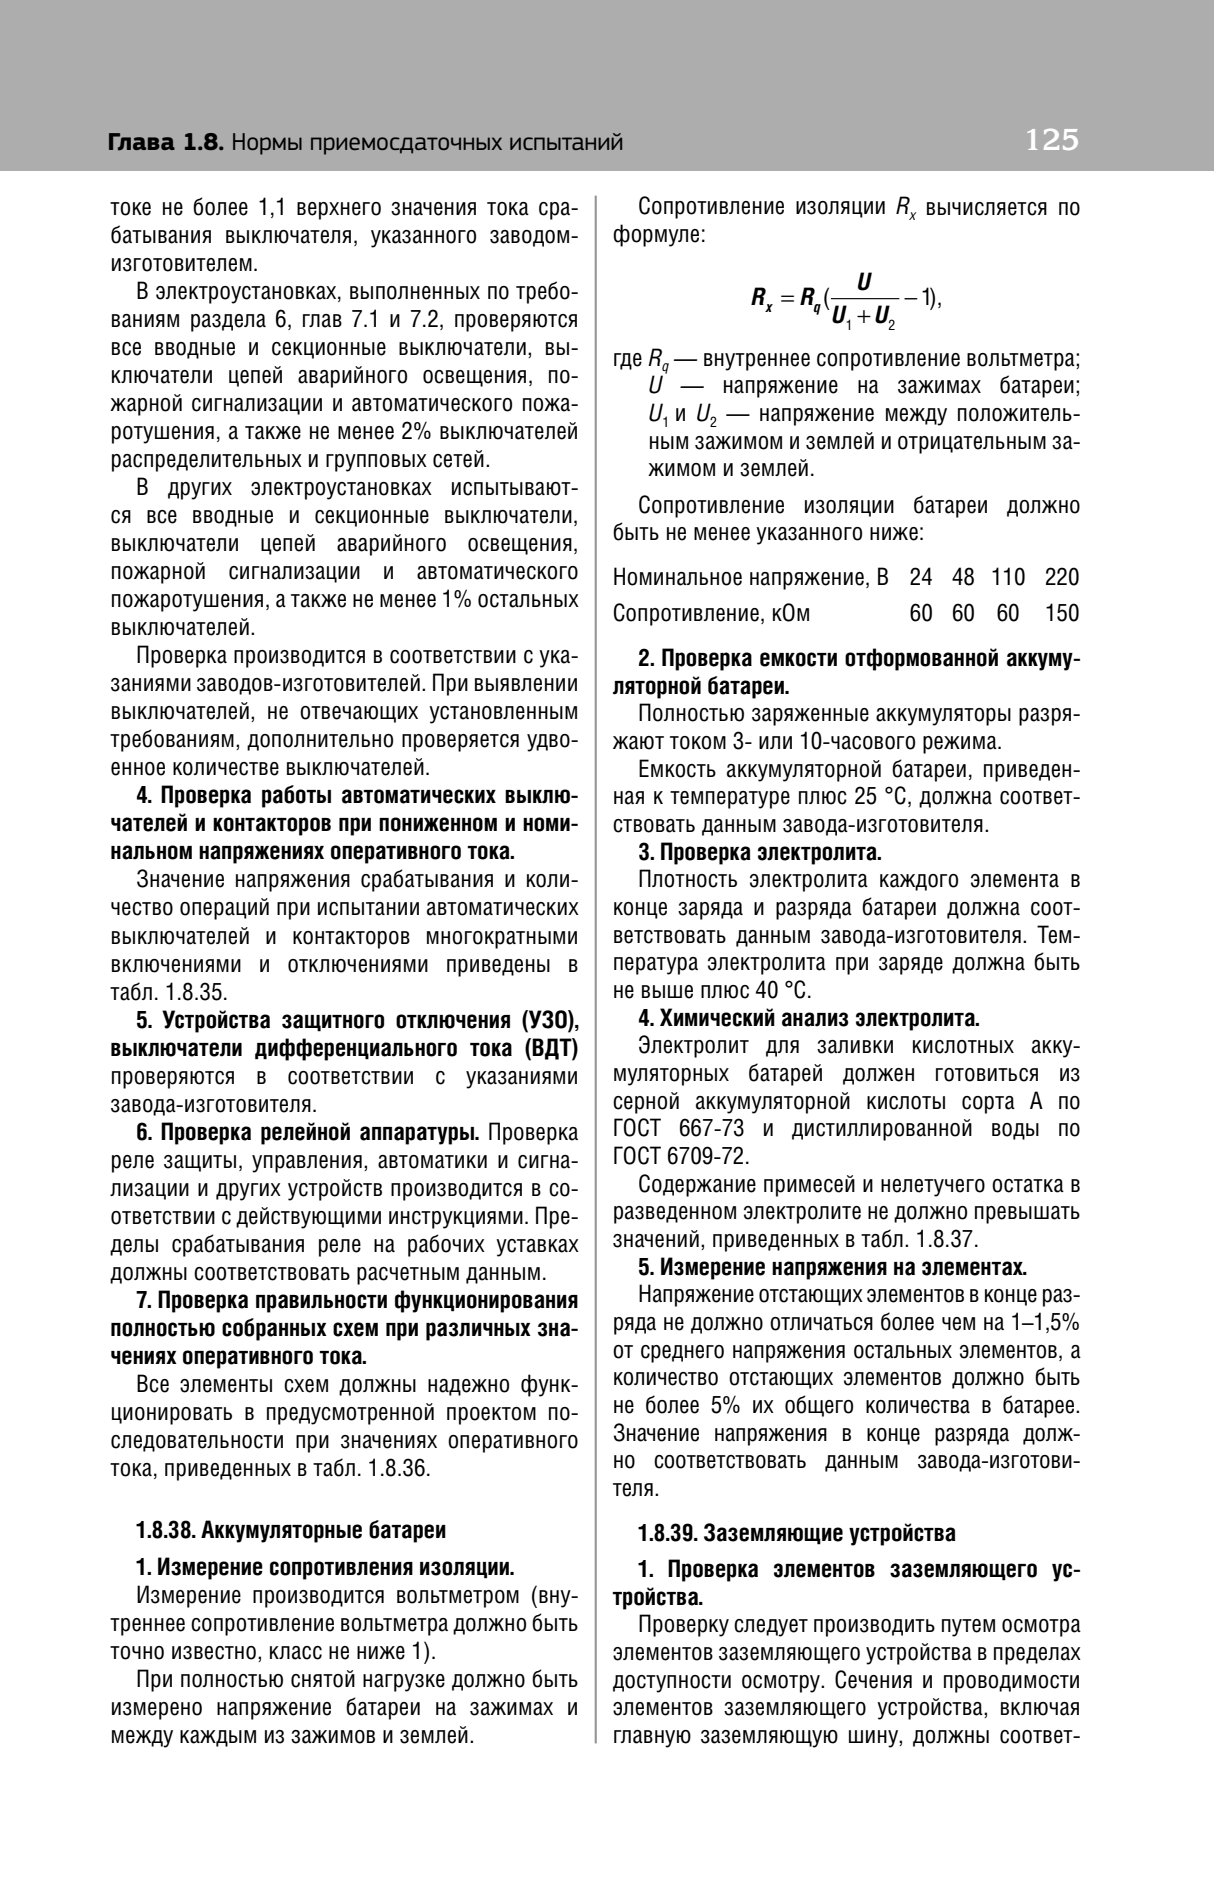

In [5]:
logger.info(f"Starting image extraction  from {pdf_file.name}...")

# Extract the target page as a PNG image
target_image = extract_page_image(
    pdf_path=pdf_file, 
    output_dir=page_images_dir
)

logger.info("Image extraction complete. Rendering preview...")

# Display the extracted image inline
display(Image(filename=target_image, width=800))

## Preparing Inputs for the Vision-Language Model (VLM)
Loading the saved Markdown into memory and converting the target image into a base64 string required by the OpenAI API spec.

In [6]:
# Load raw text
raw_markdown = raw_markdown_file.read_text(encoding="utf-8")
logger.info(f"Loaded raw Markdown: {len(raw_markdown)} characters.")

# Convert image to Base64
base64_image = encode_image_to_base64(target_image)
logger.info("Page image successfully encoded to Base64.")

2026-04-30 21:34:55 |     INFO | 002_semantic_normalization:2864798789.py:3 - Loaded raw Markdown: 4153 characters.
2026-04-30 21:34:55 |     INFO | 002_semantic_normalization:2864798789.py:7 - Page image successfully encoded to Base64.


## Agent Configuration & Data Contracts
To ensure high accuracy and output stability, the Prompt Engineering strategy is built on the following principles:
* **No Roleplay:** Avoiding roleplay leakage (e.g., "You are an expert...").
* **Token Anchoring:** Using precise, domain-specific task descriptions.
* **Task-Driven Approach:** Clear separation of constraints and output formats.
* **Language Alignment:** Prompting in the source document's language (Russian).
* **Zero Temperature:** Maximum determinism for engineering data processing.

We enforce a strict JSON output using a Pydantic schema (Explicit Chain-of-Thought with Latent Processing and strict JSON output).

As a starting point for our experiments, we use **`gpt-5-mini`** for several key reasons:

*   **High-Res Vision:** The model effectively cross-references the "dirty" Docling text with the actual PDF page geometry, which is critical for restoring ghost tables and run-in headings.
*   **Very Stable JSON:** Native support for the `.parse()` method ensures strict adherence to Pydantic data contracts without any formatting failures.
*   **Unit Economics:** It provides a good balance of cost, latency, and speed, making it perfectly suited for scaling a RAG pipeline across hundreds/thousands of documents.

In [7]:
# Setup API Client
client = OpenAI(
    api_key=os.environ.get("NANOGPT_API_KEY"),
    base_url=os.environ.get("NANOGPT_BASE_URL") 
)

TARGET_MODEL = "openai/gpt-5-mini" 
# TARGET_MODEL = "google/gemini-flash-latest"

# Load System Prompt
prompt_file = notebook_root / "prompts" / "semantic_normalization.md"
system_prompt = prompt_file.read_text(encoding="utf-8")
logger.info(f"System prompt loaded ({len(system_prompt)} chars).")

class ReasoningSteps(BaseModel):
    """
    Вложенная модель для принудительного пошагового анализа (Chain of Thought).
    """
    step_1_headings: str = Field(
        description="Найди в тексте все абзацы, начинающиеся с нумерации. Сверь с изображением: если номер и начало фразы образуют встроенный заголовок (выделены полужирным шрифтом и продолжаются обычным текстом на той же строке), подтверди их разделение. Обязательно укажи, как ты определил уровень Markdown-заголовка на основе вложенности нумерации."
    )
    step_2_tables: str = Field(
        description="Укажи, есть ли на картинке невидимые таблицы, требующие восстановления."
    )
    step_3_math: str = Field(
        description="Перечисли формулы и внутристрочные переменные, которые нужно обернуть в LaTeX."
    )
    step_4_hyphens: str = Field(
        description="Укажи разорванные слова, которые нужно склеить."
    )

class NormalizationResult(BaseModel):
    """
    Контракт данных для агента семантической нормализации.
    """
    reasoning: ReasoningSteps = Field(
        description="Пошаговый отчет о проверке структуры документа перед генерацией Markdown."
    )
    complexity_flags: List[str] = Field(
        description="Список выявленных проблем. Допустимые значения: 'run_in_heading', 'ghost_table', 'math_formula', 'hyphenation'."
    )
    clean_markdown: str = Field(
        description="Итоговый, структурно исправленный Markdown-текст. Должен сохранять 100% исходного контента без галлюцинаций."
    )

logger.info("Pydantic schema 'NormalizationResult' defined.")



2026-04-30 21:34:56 |     INFO | 002_semantic_normalization:1818487668.py:13 - System prompt loaded (3548 chars).
2026-04-30 21:34:56 |     INFO | 002_semantic_normalization:1818487668.py:46 - Pydantic schema 'NormalizationResult' defined.


## Execution (LLM Inference)
Passing the multimodal payload (Text + Image) to the model and capturing the structured response.

In [8]:
logger.info(f"Initiating semantic normalization using model: {TARGET_MODEL}")

try:
    # Constructing the multimodal payload
    messages = [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": f"Raw Markdown for processing:\n\n{raw_markdown}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}",
                        "detail": "high" # Forces the model to use high-res mode (critical for small indexes and formulas)
                    }
                }
            ]
        }
    ]

    # Execute the API call using the stable parse method for structured output
    response = client.chat.completions.parse(
        model=TARGET_MODEL,
        messages=messages,
        temperature=0.0, # Zero creativity, maximum determinism
        response_format=NormalizationResult,
    )

    # The result is automatically deserialized into our Pydantic model
    normalized_data = response.choices[0].message.parsed
    
    logger.info("LLM inference complete. Successfully parsed structured output.")
    
except Exception as e:
    logger.error(f"Failed to normalize document. Error: {e}", exc_info=True)

2026-04-30 21:34:56 |     INFO | 002_semantic_normalization:4150295336.py:1 - Initiating semantic normalization using model: openai/gpt-5-mini
2026-04-30 21:36:01 |     INFO | 002_semantic_normalization:4150295336.py:36 - LLM inference complete. Successfully parsed structured output.


## Results Evaluation & Diff Generation
Saving the healed Markdown and visually comparing it against the raw Docling output.

In [9]:
from utils.display_diff import display_diff

# Persist the results to disk
processed_dir = notebook_root / "data" / "03_processed"
processed_dir.mkdir(parents=True, exist_ok=True)

clean_markdown_file = processed_dir / f"{pdf_file.stem}_clean.md"
clean_markdown_file.write_text(normalized_data.clean_markdown, encoding="utf-8")

logger.info(f"Full clean Markdown saved to: {clean_markdown_file.name}")

# Visual Evaluation: Render Diff
logger.info("Initiating visual diff comparison...")
display_diff(
    text_before=raw_markdown, 
    text_after=normalized_data.clean_markdown,
    fromfile='Raw_Docling',
    tofile='LLM_Healed'
)

2026-04-30 21:36:01 |     INFO | 002_semantic_normalization:4110963226.py:10 - Full clean Markdown saved to: one_page_clean.md
2026-04-30 21:36:01 |     INFO | 002_semantic_normalization:4110963226.py:13 - Initiating visual diff comparison...


```diff
--- Raw_Docling
+++ LLM_Healed
@@ -1,62 +1,71 @@
-токе не более 1,1 верхнего значения тока сра -батывания выключателя , указанного заводом -изготовителем .
+токе не более 1,1 верхнего значения тока срабатывания выключателя, указанного заводом-изготовителем.
 
-В электроустановках , выполненных по требо -ваниям раздела 6, глав 7.1 и 7.2, проверяются все вводные и секционные выключатели , вы -ключатели цепей аварийного освещения , по -жарной сигнализации и автоматического пожа -ротушения , а также не менее 2% выключателей распределительных и групповых сетей .
+В электроустановках, выполненных по требованиям раздела 6, глав 7.1 и 7.2, проверяются все вводные и секционные выключатели, выключатели цепей аварийного освещения, пожарной сигнализации и автоматического пожаротушения, а также не менее 2% выключателей распределительных и групповых сетей.
 
-В других электроустановках испытывают -ся все вводные и секционные выключатели , выключатели цепей аварийного освещения , пожарной сигнализации и автоматического пожаротушения , а также не менее 1% остальных выключателей .
+В других электроустановках испытываются все вводные и секционные выключатели, выключатели цепей аварийного освещения, пожарной сигнализации и автоматического пожаротушения, а также не менее 1% остальных выключателей.
 
-Проверка производится в соответствии с ука -заниями заводов -изготовителей . При выявлении выключателей , не отвечающих установленным требованиям , дополнительно проверяется удво -енное количестве выключателей .
+Проверка производится в соответствии с указаниями заводов-изготовителей. При выявлении выключателей, не отвечающих установленным требованиям, дополнительно проверяется удвоенное количество выключателей.
 
-## 4. Проверка работы автоматических выклю -чателей и контакторов при пониженном и номи -нальном напряжениях оперативного тока .
+## 4. Проверка работы автоматических выключателей и контакторов при пониженном и номинальном напряжениях оперативного тока.
 
-Значение напряжения срабатывания и коли -чество операций при испытании автоматических выключателей и контакторов многократными включениями и отключениями приведены в табл . 1.8.35.
+Значение напряжения срабатывания и количество операций при испытании автоматических выключателей и контакторов многократными включениями и отключениями приведены в табл. 1.8.35.
 
-5. Устройства защитного отключения ( УЗО ), выключатели дифференциального тока ( ВДТ ) проверяются в соответствии с указаниями завода -изготовителя .
-6. Проверка релейной аппаратуры . Проверка реле защиты , управления , автоматики и сигна -лизации и других устройств производится в со -ответствии с действующими инструкциями . Пре -делы срабатывания реле на рабочих уставках должны соответствовать расчетным данным .
+## 5. Устройства защитного отключения (УЗО), выключатели дифференциального тока (ВДТ)
 
-## 7. Проверка правильности функционирования полностью собранных схем при различных зна -чениях оперативного тока .
+проверяются в соответствии с указаниями завода-изготовителя.
 
-Все элементы схем должны надежно функ -ционировать в предусмотренной проектом по -следовательности при значениях оперативного тока , приведенных в табл . 1.8.36.
+## 6. Проверка релейной аппаратуры.
+
+Проверка реле защиты, управления, автоматики и сигнализации и других устройств производится в соответствии с действующими инструкциями. Пределы срабатывания реле на рабочих уставках должны соответствовать расчетным данным.
+
+## 7. Проверка правильности функционирования полностью собранных схем при различных значениях оперативного тока.
+
+Все элементы схем должны надежно функционировать в предусмотренной проектом последовательности при значениях оперативного тока, приведенных в табл. 1.8.36.
 
 ## 1.8.38. Аккумуляторные батареи
 
-## 1. Измерение сопротивления изоляции .
+### 1. Измерение сопротивления изоляции.
 
-Измерение производится вольтметром ( вну -треннее сопротивление вольтметра должно быть точно известно , класс не ниже 1).
+Измерение производится вольтметром (внутреннее сопротивление вольтметра должно быть точно известно, класс не ниже 1).
 
-При полностью снятой нагрузке должно быть измерено напряжение батареи на зажимах и между каждым из зажимов и землей .
+При полностью снятой нагрузке должно быть измерено напряжение батареи на зажимах и между каждым из зажимов и землей.
 
-Сопротивление изоляции R x вычисляется по формуле :
+Сопротивление изоляции $R_x$ вычисляется по формуле:
 
-$$R _ { x } = R _ { \varrho } ( \frac { u } { u _ { 1 } + u _ { 2 } } - 1 ) ,$$
+$$
+R_x = R_q\left(\frac{U}{U_1 + U_2} - 1\right),
+$$
 
-где R q -внутреннее сопротивление вольтметра ; U  напряжение на зажимах батареи ; U 1 и U 2 -напряжение между положитель -ным зажимом и землей и отрицательным за -жимом и землей .
+где $R_q$ — внутреннее сопротивление вольтметра; $U$ — напряжение на зажимах батареи; $U_1$ и $U_2$ — напряжение между положительным зажимом и землей и отрицательным зажимом и землей.
 
-Сопротивление изоляции батареи должно быть не менее указанного ниже :
+Сопротивление изоляции батареи должно быть не менее указанного ниже:
 
-Номинальное напряжение , В 24 48 110 220 Сопротивление , кОм 60 60 60 150
+| Номинальное напряжение, В | 24 | 48 | 110 | 220 |
+|---|---:|---:|---:|---:|
+| Сопротивление, кОм | 60 | 60 | 60 | 150 |
 
-## 2. Проверка емкости отформованной аккуму -ляторной батареи .
+### 2. Проверка емкости отформованной аккумуляторной батареи.
 
-Полностью заряженные аккумуляторы разря -жают током 3или 10часового режима .
+Полностью заряженные аккумуляторы разряжают током 3- или 10-часового режима.
 
-Емкость аккумуляторной батареи , приведен -ная к температуре плюс 25 ° С , должна соответ -ствовать данным завода -изготовителя .
+Емкость аккумуляторной батареи, приведенная к температуре плюс 25 °С, должна соответствовать данным завода-изготовителя.
 
-## 3. Проверка электролита .
+### 3. Проверка электролита.
 
-Плотность электролита каждого элемента в конце заряда и разряда батареи должна соот -ветствовать данным завода -изготовителя . Тем -пература электролита при заряде должна быть не выше плюс 40 ° С .
+Плотность электролита каждого элемента в конце заряда и разряда батареи должна соответствовать данным завода-изготовителя. Температура электролита при заряде должна быть не выше плюс 40 °С.
 
-## 4. Химический анализ электролита .
+### 4. Химический анализ электролита.
 
-Электролит для заливки кислотных акку -муляторных батарей должен готовиться из серной аккумуляторной кислоты сорта А по ГОСТ 667-73 и дистиллированной воды по ГОСТ 6709-72.
+Электролит для заливки кислотных аккумуляторных батарей должен готовиться из серной аккумуляторной кислоты сорта А по ГОСТ 667-73 и дистиллированной воды по ГОСТ 6709-72.
 
-Содержание примесей и нелетучего остатка в разведенном электролите не должно превышать значений , приведенных в табл . 1.8.37.
+Содержание примесей и нелетучего остатка в разведенном электролите не должно превышать значений, приведенных в табл. 1.8.37.
 
-## 5. Измерение напряжения на элементах .
+### 5. Измерение напряжения на элементах.
 
-Напряжение отстающих элементов в конце раз -ряда не должно отличаться более чем на 1-1,5% от среднего напряжения остальных элементов , а количество отстающих элементов должно быть не более 5% их общего количества в батарее . Значение напряжения в конце разряда долж -но соответствовать данным завода -изготови -теля .
+Напряжение отстающих элементов в конце разряда не должно отличаться более чем на 1-1,5% от среднего напряжения остальных элементов, а количество отстающих элементов должно быть не более 5% их общего количества в батарее. Значение напряжения в конце разряда должно соответствовать данным завода-изготовителя.
 
 ## 1.8.39. Заземляющие устройства
 
-## 1. Проверка элементов заземляющего ус -тройства .
+### 1. Проверка элементов заземляющего устройства.
 
-Проверку следует производить путем осмотра элементов заземляющего устройства в пределах доступности осмотру . Сечения и проводимости элементов заземляющего устройства , включая главную заземляющую шину , должны соответ -
+Проверку следует производить путем осмотра элементов заземляющего устройства в пределах доступности осмотру. Сечения и проводимости элементов заземляющего устройства, включая главную заземляющую шину, должны соответ-
```

## Native Chain of Thought (Native CoT)

In this experiment, we remove the strict JSON fields for reasoning. We use a lightweight data schema and move the analysis logic directly into the system prompt. This should allow the model to leverage its native, more efficient Chain of Thought mechanism (Implicit Chain-of-Thought / Latent Reasoning).

In [32]:
# Load the updated system prompt
prompt_file_cot = notebook_root / "prompts" / "semantic_normalization_native_cot.md"
system_prompt_cot = prompt_file_cot.read_text(encoding="utf-8")
logger.info(f"Native CoT System prompt loaded ({len(system_prompt_cot)} chars).")

class NormalizationResultLight(BaseModel):
    """
    Lightweight data contract. The agent returns only the final result,
    while all reasoning logic happens "under the hood" via native CoT.
    """
    complexity_flags: List[str] = Field(
        description="List of identified issues. Allowed values: 'run_in_heading', 'ghost_table', 'math_formula', 'hyphenation', 'detached_punctuation'."
    )
    clean_markdown: str = Field(
        description="Final, structurally corrected Markdown text. Must retain 100% of the original content."
    )

logger.info("Pydantic schema 'NormalizationResultLight' defined.")

2026-04-30 22:44:57 |     INFO | 002_semantic_normalization:2981511528.py:4 - Native CoT System prompt loaded (3834 chars).
2026-04-30 22:44:57 |     INFO | 002_semantic_normalization:2981511528.py:18 - Pydantic schema 'NormalizationResultLight' defined.


In [33]:
logger.info(f"Initiating Experiment 2 (Native CoT) using model: {TARGET_MODEL}")

try:
    messages_cot = [
        {"role": "system", "content": system_prompt_cot},
        {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": f"Raw Markdown for processing:\n\n{raw_markdown}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}",
                        "detail": "high"
                    }
                }
            ]
        }
    ]

    response_cot = client.chat.completions.parse(
        model=TARGET_MODEL,
        messages=messages_cot,
        temperature=0.0,
        response_format=NormalizationResultLight,
    )

    normalized_data_cot = response_cot.choices[0].message.parsed
except Exception as e:
    logger.error(f"Failed to run Experiment 2. Error: {e}", exc_info=True)

2026-04-30 22:44:57 |     INFO | 002_semantic_normalization:639202334.py:1 - Initiating Experiment 2 (Native CoT) using model: openai/gpt-5-mini


In [34]:
# Persist the Native CoT results to disk
processed_dir = notebook_root / "data" / "03_processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# Save the md-file
clean_markdown_cot_file = processed_dir / f"{pdf_file.stem}_clean_cot.md"
clean_markdown_cot_file.write_text(normalized_data_cot.clean_markdown, encoding="utf-8")

logger.info(f"Native CoT clean Markdown saved to: {clean_markdown_cot_file.name}")

# Visual Evaluation: Render Diff for Native CoT
from utils.display_diff import display_diff

logger.info("Initiating visual diff comparison for Native CoT...")
display_diff(
    text_before=raw_markdown, 
    text_after=normalized_data_cot.clean_markdown,
    fromfile='Raw_Docling',
    tofile='LLM_Healed_Native_CoT'
)

2026-04-30 22:46:01 |     INFO | 002_semantic_normalization:2698477842.py:9 - Native CoT clean Markdown saved to: one_page_clean_cot.md
2026-04-30 22:46:01 |     INFO | 002_semantic_normalization:2698477842.py:14 - Initiating visual diff comparison for Native CoT...


```diff
--- Raw_Docling
+++ LLM_Healed_Native_CoT
@@ -1,62 +1,69 @@
-токе не более 1,1 верхнего значения тока сра -батывания выключателя , указанного заводом -изготовителем .
+токе не более 1,1 верхнего значения тока срабатывания выключателя, указанного заводом-изготовителем.
 
-В электроустановках , выполненных по требо -ваниям раздела 6, глав 7.1 и 7.2, проверяются все вводные и секционные выключатели , вы -ключатели цепей аварийного освещения , по -жарной сигнализации и автоматического пожа -ротушения , а также не менее 2% выключателей распределительных и групповых сетей .
+В электроустановках, выполненных по требованиям раздела 6, глав 7.1 и 7.2, проверяются все вводные и секционные выключатели, выключатели цепей аварийного освещения, пожарной сигнализации и автоматического пожаротушения, а также не менее 2% выключателей распределительных и групповых сетей.
 
-В других электроустановках испытывают -ся все вводные и секционные выключатели , выключатели цепей аварийного освещения , пожарной сигнализации и автоматического пожаротушения , а также не менее 1% остальных выключателей .
+В других электроустановках испытываются все вводные и секционные выключатели, выключатели цепей аварийного освещения, пожарной сигнализации и автоматического пожаротушения, а также не менее 1% остальных выключателей.
 
-Проверка производится в соответствии с ука -заниями заводов -изготовителей . При выявлении выключателей , не отвечающих установленным требованиям , дополнительно проверяется удво -енное количестве выключателей .
+Проверка производится в соответствии с указаниями заводов-изготовителей. При выявлении выключателей, не отвечающих установленным требованиям, дополнительно проверяется удвоенное количество выключателей.
 
-## 4. Проверка работы автоматических выклю -чателей и контакторов при пониженном и номи -нальном напряжениях оперативного тока .
+#### 4. Проверка работы автоматических выключателей и контакторов при пониженном и номинальном напряжениях оперативного тока.
 
-Значение напряжения срабатывания и коли -чество операций при испытании автоматических выключателей и контакторов многократными включениями и отключениями приведены в табл . 1.8.35.
+Значение напряжения срабатывания и количество операций при испытании автоматических выключателей и контакторов многократными включениями и отключениями приведены в табл. 1.8.35.
 
-5. Устройства защитного отключения ( УЗО ), выключатели дифференциального тока ( ВДТ ) проверяются в соответствии с указаниями завода -изготовителя .
-6. Проверка релейной аппаратуры . Проверка реле защиты , управления , автоматики и сигна -лизации и других устройств производится в со -ответствии с действующими инструкциями . Пре -делы срабатывания реле на рабочих уставках должны соответствовать расчетным данным .
+#### 5. Устройства защитного отключения (УЗО), выключатели дифференциального тока (ВДТ)
 
-## 7. Проверка правильности функционирования полностью собранных схем при различных зна -чениях оперативного тока .
+проверяются в соответствии с указаниями завода-изготовителя.
 
-Все элементы схем должны надежно функ -ционировать в предусмотренной проектом по -следовательности при значениях оперативного тока , приведенных в табл . 1.8.36.
+#### 6. Проверка релейной аппаратуры.
 
-## 1.8.38. Аккумуляторные батареи
+Проверка реле защиты, управления, автоматики и сигнализации и других устройств производится в соответствии с действующими инструкциями. Пределы срабатывания реле на рабочих уставках должны соответствовать расчетным данным.
 
-## 1. Измерение сопротивления изоляции .
+#### 7. Проверка правильности функционирования полностью собранных схем при различных значениях оперативного тока.
 
-Измерение производится вольтметром ( вну -треннее сопротивление вольтметра должно быть точно известно , класс не ниже 1).
+Все элементы схем должны надежно функционировать в предусмотренной проектом последовательности при значениях оперативного тока, приведенных в табл. 1.8.36.
 
-При полностью снятой нагрузке должно быть измерено напряжение батареи на зажимах и между каждым из зажимов и землей .
+### 1.8.38. Аккумуляторные батареи
 
-Сопротивление изоляции R x вычисляется по формуле :
+#### 1. Измерение сопротивления изоляции.
 
-$$R _ { x } = R _ { \varrho } ( \frac { u } { u _ { 1 } + u _ { 2 } } - 1 ) ,$$
+Измерение производится вольтметром (внутреннее сопротивление вольтметра должно быть точно известно, класс не ниже 1).
 
-где R q -внутреннее сопротивление вольтметра ; U  напряжение на зажимах батареи ; U 1 и U 2 -напряжение между положитель -ным зажимом и землей и отрицательным за -жимом и землей .
+При полностью снятой нагрузке должно быть измерено напряжение батареи на зажимах и между каждым из зажимов и землей.
 
-Сопротивление изоляции батареи должно быть не менее указанного ниже :
+Сопротивление изоляции $R_x$ вычисляется по формуле:
 
-Номинальное напряжение , В 24 48 110 220 Сопротивление , кОм 60 60 60 150
+$$R_x = R_q\left(\frac{U}{U_1+U_2}-1\right),$$
 
-## 2. Проверка емкости отформованной аккуму -ляторной батареи .
+где $R_q$ — внутреннее сопротивление вольтметра; $U$ — напряжение на зажимах батареи; $U_1$ и $U_2$ — напряжение между положительным зажимом и землей и отрицательным зажимом и землей.
 
-Полностью заряженные аккумуляторы разря -жают током 3или 10часового режима .
+Сопротивление изоляции батареи должно быть не менее указанного ниже:
 
-Емкость аккумуляторной батареи , приведен -ная к температуре плюс 25 ° С , должна соответ -ствовать данным завода -изготовителя .
+| Номинальное напряжение, В | 24 | 48 | 110 | 220 |
+|---|---:|---:|---:|---:|
+| Сопротивление, кОм | 60 | 60 | 60 | 150 |
 
-## 3. Проверка электролита .
+#### 2. Проверка емкости отформованной аккумуляторной батареи.
 
-Плотность электролита каждого элемента в конце заряда и разряда батареи должна соот -ветствовать данным завода -изготовителя . Тем -пература электролита при заряде должна быть не выше плюс 40 ° С .
+Полностью заряженные аккумуляторы разряжают током 3- или 10-часового режима.
 
-## 4. Химический анализ электролита .
+Емкость аккумуляторной батареи, приведенная к температуре плюс 25 °С, должна соответствовать данным завода-изготовителя.
 
-Электролит для заливки кислотных акку -муляторных батарей должен готовиться из серной аккумуляторной кислоты сорта А по ГОСТ 667-73 и дистиллированной воды по ГОСТ 6709-72.
+#### 3. Проверка электролита.
 
-Содержание примесей и нелетучего остатка в разведенном электролите не должно превышать значений , приведенных в табл . 1.8.37.
+Плотность электролита каждого элемента в конце заряда и разряда батареи должна соответствовать данным завода-изготовителя. Температура электролита при заряде должна быть не выше плюс 40 °С.
 
-## 5. Измерение напряжения на элементах .
+#### 4. Химический анализ электролита.
 
-Напряжение отстающих элементов в конце раз -ряда не должно отличаться более чем на 1-1,5% от среднего напряжения остальных элементов , а количество отстающих элементов должно быть не более 5% их общего количества в батарее . Значение напряжения в конце разряда долж -но соответствовать данным завода -изготови -теля .
+Электролит для заливки кислотных аккумуляторных батарей должен готовиться из серной аккумуляторной кислоты сорта А по ГОСТ 667-73 и дистиллированной воды по ГОСТ 6709-72.
 
-## 1.8.39. Заземляющие устройства
+Содержание примесей и нелетучего остатка в разведенном электролите не должно превышать значений, приведенных в табл. 1.8.37.
 
-## 1. Проверка элементов заземляющего ус -тройства .
+#### 5. Измерение напряжения на элементах.
 
-Проверку следует производить путем осмотра элементов заземляющего устройства в пределах доступности осмотру . Сечения и проводимости элементов заземляющего устройства , включая главную заземляющую шину , должны соответ -
+Напряжение отстающих элементов в конце разряда не должно отличаться более чем на 1-1,5% от среднего напряжения остальных элементов, а количество отстающих элементов должно быть не более 5% их общего количества в батарее. Значение напряжения в конце разряда должно соответствовать данным завода-изготовителя.
+
+### 1.8.39. Заземляющие устройства
+
+#### 1. Проверка элементов заземляющего устройства.
+
+Проверку следует производить путем осмотра элементов заземляющего устройства в пределах доступности осмотру. Сечения и проводимости элементов заземляющего устройства, включая главную заземляющую шину, должны соответ-
```

## Conclusions & Next Steps

**1. Primary Parsing (Docling)**
Using raw `docling` handles page geometry and schematic isolation excellently (with OCR disabled). However, it leaves critical structural artifacts: it fails to recognize run-in headings, loses inline formulas, and breaks borderless ghost tables.

**2. LLM Normalization (Forced CoT vs. Native CoT)**
A Vision-Language Model (VLM) was applied to "heal" the raw Markdown. We compared two approaches:
* **Strict JSON-CoT:** The model was forced to explicitly output its reasoning steps. It works, but lacks stability. In 20-30% of cases, the model confuses the nesting levels of run-in headings and loses inline variables/formulas.
* **Native CoT (Algorithm in System Prompt):** Removing the strict JSON schema didn't significantly change the quality (the same 20-30% error rate on complex elements), but it provided a massive resource gain: **output token consumption dropped by 30-50%**, and response speed noticeably increased. We are adopting this as our baseline approach.

**3. Why We Avoid Few-Shot Prompting**
Despite the general effectiveness of Few-Shot prompting, we consciously decided against embedding examples in the prompt. We are building a domain-agnostic pipeline and want to avoid overfitting the agent to specific formats (like PUE). Visual formatting rules in GOSTs, SNiPs, or local technical specifications can fundamentally contradict each other.

**4. Next Steps: Semantic XML Tagging**
The current baseline is decent, but more complex multi-page cases lie ahead. To break through the 20-30% error ceiling, we plan to introduce **Semantic XML Tagging (Unique XML Tagging)** into the raw text before feeding it to the LLM. We will wrap the Docling AST nodes in unique tags (e.g., `<list_item_1>`) to create "ironclad" attention boundaries for the model and prevent context blending. We will evaluate whether this yields 100% stability or if this level of prompt engineering proves to be overkill for the final vector RAG database.